# 08 - Cross-Dataset Generalisation

This is the notebook that answers the objection the original submission could not: does
the method generalise, or was it tuned to one campus fibre?

Four experiments, in increasing order of difficulty:

1. **Parallel benchmark** - the identical pipeline run on both datasets. Do the same
   domains, selectors and classifiers rank the same way on two different interrogators?
2. **Cross-system transfer** - train on one dataset, test on the other, using a
   harmonised 4-class taxonomy and only the signal-agnostic feature domains.
3. **Leave-one-campaign-out (Cao)** - hold out whole acquisition dates.
4. **Leave-one-recording-out (Tomasov)** - for the four classes that have >= 2 recordings.

Plus a sampling-rate sensitivity check for Cao, whose release does not record which
fibre span each file came from.

## Why the original paper's objection does not apply

The submitted version argued Cao was unsuitable for validation: different sensing
principle, only one overlapping class, only 12 spatial channels. All three are true, and
all three only rule out *naive transfer of a fitted model*. They do not rule out
**re-running the methodology** and comparing what it concludes - which is what
experiment 1 does, and which is the claim the paper actually wants to make.

In [1]:
import sys, json, itertools
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from dasfe import config as C, fusion as F, evaluate as EV, selection as FS, splits as S

sns.set_theme(style="whitegrid", context="notebook")

SMOKE_TEST = False
suffix = "_smoke" if SMOKE_TEST else ""
out_dir = C.results_dir("shared", "08_crossdataset" + suffix)

def load(ds):
    d = F.load(C.results_dir(ds, "04_fusion" + suffix))
    d["split"] = d["manifest"]["split"].to_numpy()
    return d

DS = {ds: load(ds) for ds in ("cao", "tomasov")}
for ds, d in DS.items():
    print(f"{ds:8s} X {d['X'].shape}  classes {sorted(set(d['y']))}")

cao      X (15418, 1002)  classes ['background', 'dig', 'knock', 'shake', 'walk', 'water']
tomasov  X (172458, 1002)  classes ['car', 'construction', 'fence', 'longboard', 'manipulation', 'openclose', 'regular', 'running', 'walk']


## 1. Parallel benchmark - does the method rank things the same way on both systems?

If the time-frequency domain is strongest on Cao and on Tomasov, and LightGBM wins on
both, then the conclusion is about the *method*. If the rankings disagree, the original
single-dataset conclusion was an artefact.

In [2]:
DOMAIN_SLICES = {"time": slice(0, 112), "freq": slice(112, 202),
                 "tf": slice(202, 941), "spatial": slice(941, 1002),
                 "multi": slice(0, 1002)}
FAST_MODELS = ["LightGBM", "XGBoost", "RandomForest"]
FAST_STRATS = ["none", "class_weight"]

rows = []
for ds, d in DS.items():
    for dom, sl in DOMAIN_SLICES.items():
        b = EV.benchmark(d["X"][:, sl], d["y"], d["split"],
                         model_names=FAST_MODELS, strategies=FAST_STRATS,
                         seed=C.SEED, verbose=False)
        top = b.iloc[0]
        rows.append({"dataset": ds, "domain": dom, "n_features": sl.stop - sl.start,
                     "best_model": top.model, "best_strategy": top.strategy,
                     "test_accuracy": 100*top.test_accuracy,
                     "test_f1_macro": 100*top.test_f1_macro})
        print(f"  {ds:8s} {dom:8s} F1 {100*top.test_f1_macro:5.2f}%  ({top.model})")

parallel = pd.DataFrame(rows)
display(parallel.round(2))
parallel.to_csv(out_dir / "parallel_domain_benchmark.csv", index=False)

  cao      time     F1 90.69%  (LightGBM)
  cao      freq     F1 78.88%  (LightGBM)
  cao      tf       F1 92.51%  (LightGBM)
  cao      spatial  F1 95.42%  (LightGBM)
  cao      multi    F1 98.89%  (LightGBM)
  tomasov  time     F1 54.82%  (LightGBM)
  tomasov  freq     F1 55.23%  (LightGBM)
  tomasov  tf       F1 58.98%  (LightGBM)
  tomasov  spatial  F1 75.58%  (LightGBM)
  tomasov  multi    F1 81.82%  (LightGBM)


,dataset,domain,n_features,best_model,best_strategy,test_accuracy,test_f1_macro
0,cao,time,112,LightGBM,none,92.29,90.69
1,cao,freq,90,LightGBM,class_weight,81.81,78.88
2,cao,tf,739,LightGBM,class_weight,94.34,92.51
3,cao,spatial,61,LightGBM,none,96.34,95.42
4,cao,multi,1002,LightGBM,class_weight,99.06,98.89
5,tomasov,time,112,LightGBM,class_weight,55.04,54.82
6,tomasov,freq,90,LightGBM,class_weight,57.56,55.23
7,tomasov,tf,739,LightGBM,class_weight,59.30,58.98
8,tomasov,spatial,61,LightGBM,class_weight,87.20,75.58
9,tomasov,multi,1002,LightGBM,class_weight,90.82,81.82


dataset,cao,tomasov,cao_rank,tomasov_rank
domain,,,,
freq,78.88,55.23,5.0,4.0
multi,98.89,81.82,1.0,1.0
spatial,95.42,75.58,2.0,2.0
tf,92.51,58.98,3.0,3.0
time,90.69,54.82,4.0,5.0



Spearman rank correlation of domain performance across datasets: rho = 0.900 (p = 0.0374)
A high positive rho means the domain ranking is a property of the method,
not of one dataset.


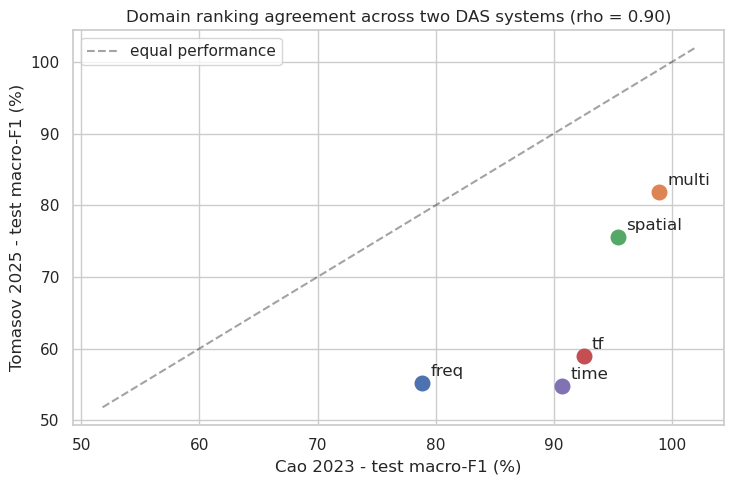

In [3]:
piv = parallel.pivot(index="domain", columns="dataset", values="test_f1_macro")
piv["cao_rank"] = piv.cao.rank(ascending=False)
piv["tomasov_rank"] = piv.tomasov.rank(ascending=False)
display(piv.round(2))

rho, p = spearmanr(piv.cao, piv.tomasov)
print(f"\nSpearman rank correlation of domain performance across datasets: "
      f"rho = {rho:.3f} (p = {p:.4f})")
print("A high positive rho means the domain ranking is a property of the method,")
print("not of one dataset.")

fig, ax = plt.subplots(figsize=(7.5, 5))
for dom in piv.index:
    ax.scatter(piv.loc[dom, "cao"], piv.loc[dom, "tomasov"], s=110)
    ax.annotate(dom, (piv.loc[dom, "cao"], piv.loc[dom, "tomasov"]),
                xytext=(6, 5), textcoords="offset points")
lims = [min(piv.cao.min(), piv.tomasov.min()) - 3, max(piv.cao.max(), piv.tomasov.max()) + 3]
ax.plot(lims, lims, "k--", alpha=0.4, label="equal performance")
ax.set_xlabel("Cao 2023 - test macro-F1 (%)"); ax.set_ylabel("Tomasov 2025 - test macro-F1 (%)")
ax.set_title(f"Domain ranking agreement across two DAS systems (rho = {rho:.2f})")
ax.legend(); plt.tight_layout()
plt.savefig(out_dir / "domain_ranking_agreement.png", dpi=200)
plt.show()

### 1.1 Do the selectors agree across datasets?

Feature-selection stability across two independent acquisitions is a much stronger claim
than stability across folds of one acquisition.

In [4]:
stab = {}
for ds in DS:
    t = pd.read_csv(C.results_dir(ds, "05_selection" + suffix) / "fs_table_multi.csv")
    stab[ds] = t.set_index("feature")["selection_pct"]

joint = pd.DataFrame(stab).dropna()
rho_f, p_f = spearmanr(joint.cao, joint.tomasov)
print(f"features scored on both datasets: {len(joint)}")
print(f"Spearman rho of per-feature selection rate: {rho_f:.3f} (p = {p_f:.2e})")

both_unanimous = joint[(joint.cao >= 99) & (joint.tomasov >= 99)]
print(f"\nfeatures unanimously selected on BOTH datasets: {len(both_unanimous)}")
display(both_unanimous.head(25))
both_unanimous.to_csv(out_dir / "features_stable_across_datasets.csv")

features scored on both datasets: 1002
Spearman rho of per-feature selection rate: 0.551 (p = 1.30e-80)

features unanimously selected on BOTH datasets: 5


,cao,tomasov
feature,,
TF:Et_min,100.0,100.0
TF:Et_p25,100.0,100.0
TF:Et_range,100.0,100.0
TF:flux_max,100.0,100.0
TIME:energy_gini,100.0,100.0


## 2. Cross-system transfer on a harmonised taxonomy

The two taxonomies are not identical, but they are not disjoint either. Four event types
have a defensible physical correspondence:

| harmonised class | Cao | Tomasov |
|---|---|---|
| `background` | background | regular |
| `walk` | walk | walk |
| `impact` | knock | fence (knocking on a fence) |
| `excavation` | dig | construction |

Transfer uses **only the time, frequency and time-frequency domains**. The spatial
descriptors are deliberately excluded: they depend on channel spacing (10 m vs 1.02 m)
and channel count (12 vs 32), so transferring them would be meaningless rather than
merely hard.

This is a hard test and low absolute numbers are expected. It is reported because a
cross-system floor is more informative than another within-dataset ceiling.

In [5]:
HARMONISED = {
    "cao":     {"background": "background", "walk": "walk", "knock": "impact", "dig": "excavation"},
    "tomasov": {"regular": "background", "walk": "walk", "fence": "impact",
                "construction": "excavation"},
}
SIGNAL_AGNOSTIC = slice(0, 941)      # time + freq + tf; spatial excluded

def harmonise(ds):
    d = DS[ds]
    m = HARMONISED[ds]
    keep = np.isin(d["y"], list(m))
    return d["X"][keep][:, SIGNAL_AGNOSTIC], np.array([m[v] for v in d["y"][keep]]), d["split"][keep]

Xc, yc, sc = harmonise("cao")
Xt, yt, st = harmonise("tomasov")
print(f"cao      {Xc.shape}  {pd.Series(yc).value_counts().to_dict()}")
print(f"tomasov  {Xt.shape}  {pd.Series(yt).value_counts().to_dict()}")
print(f"\nfeatures used: {Xc.shape[1]} (spatial domain excluded)")

cao      (10437, 941)  {'background': 2945, 'impact': 2530, 'excavation': 2512, 'walk': 2450}
tomasov  (95985, 941)  {'impact': 38115, 'excavation': 27420, 'walk': 18101, 'background': 12349}

features used: 941 (spatial domain excluded)


In [6]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer

def transfer(Xa, ya, Xb, yb, name, normaliser="quantile"):
    """Train on A, test on B.  The normaliser is fitted on A only."""
    if normaliser == "quantile":
        nz = QuantileTransformer(output_distribution="normal", n_quantiles=min(1000, len(Xa)),
                                 random_state=C.SEED)
    else:
        nz = StandardScaler()
    Xa_n = nz.fit_transform(Xa)
    Xb_n = nz.transform(Xb)
    r = EV.fit_predict("LightGBM", "class_weight", Xa_n, ya, Xb_n, yb, C.SEED)
    labels = sorted(set(ya) & set(yb))
    return {"direction": name,
            "n_train": len(ya), "n_test": len(yb),
            "accuracy": 100*r["metrics"]["accuracy"],
            "balanced_accuracy": 100*r["metrics"]["balanced_accuracy"],
            "f1_macro": 100*r["metrics"]["f1_macro"]}, r, labels

res_ct, r_ct, lab = transfer(Xc, yc, Xt, yt, "Cao -> Tomasov")
res_tc, r_tc, _   = transfer(Xt, yt, Xc, yc, "Tomasov -> Cao")

# Within-dataset reference on the same 4 classes, for context.
ref = []
for nm, Xd, yd, sd in [("Cao (within)", Xc, yc, sc), ("Tomasov (within)", Xt, yt, st)]:
    r = EV.fit_predict("LightGBM", "class_weight",
                       Xd[sd == "train"], yd[sd == "train"],
                       Xd[sd == "test"], yd[sd == "test"], C.SEED)
    ref.append({"direction": nm, "n_train": int((sd=="train").sum()),
                "n_test": int((sd=="test").sum()),
                "accuracy": 100*r["metrics"]["accuracy"],
                "balanced_accuracy": 100*r["metrics"]["balanced_accuracy"],
                "f1_macro": 100*r["metrics"]["f1_macro"]})

xfer = pd.DataFrame(ref + [res_ct, res_tc])
display(xfer.round(2))
xfer.to_csv(out_dir / "cross_system_transfer.csv", index=False)
print(f"\nchance level for {len(lab)} classes: {100/len(lab):.1f}% accuracy")

,direction,n_train,n_test,accuracy,balanced_accuracy,f1_macro
0,Cao (within),7888,1451,95.93,94.57,94.45
1,Tomasov (within),81645,6987,73.02,69.29,70.01
2,Cao -> Tomasov,10437,95985,14.41,21.66,12.97
3,Tomasov -> Cao,95985,10437,19.12,20.02,15.99



chance level for 4 classes: 25.0% accuracy


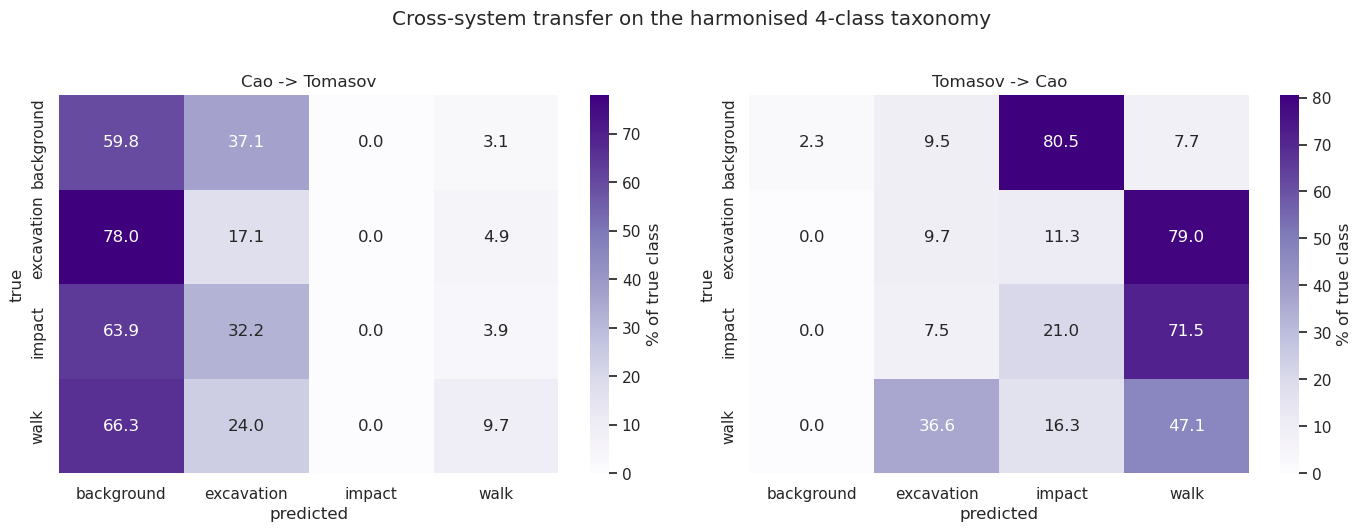

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, (r, yb, title) in zip(axes, [(r_ct, yt, "Cao -> Tomasov"), (r_tc, yc, "Tomasov -> Cao")]):
    cm = EV.confusion(yb, r["y_pred"], labels=lab, normalize="true")
    sns.heatmap(100*cm, annot=True, fmt=".1f", cmap="Purples", ax=ax,
                cbar_kws={"label": "% of true class"})
    ax.set_title(title); ax.set_xlabel("predicted"); ax.set_ylabel("true")
fig.suptitle("Cross-system transfer on the harmonised 4-class taxonomy", y=1.02)
plt.tight_layout()
plt.savefig(out_dir / "cross_system_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Leave-one-campaign-out (Cao)

Session-grouping prevents within-recording leakage but still lets the same day appear in
train and test. Holding out whole dates tests robustness to day-to-day changes in soil
moisture, temperature and operator technique.

In [8]:
cao_m = DS["cao"]["manifest"]
Xc_all, yc_all = DS["cao"]["X"], DS["cao"]["y"]
dates = cao_m["date"].to_numpy()

lodo = []
for d in sorted(pd.unique(dates)):
    te = dates == d
    tr = ~te
    if te.sum() < 30 or len(np.unique(yc_all[te])) < 2 or len(np.unique(yc_all[tr])) < 2:
        continue
    r = EV.fit_predict("LightGBM", "class_weight", Xc_all[tr], yc_all[tr],
                       Xc_all[te], yc_all[te], C.SEED)
    lodo.append({"held_out_date": d, "n_test": int(te.sum()),
                 "n_classes_in_test": int(len(np.unique(yc_all[te]))),
                 "accuracy": 100*r["metrics"]["accuracy"],
                 "f1_macro": 100*r["metrics"]["f1_macro"]})
lodo = pd.DataFrame(lodo)
display(lodo.round(2))

if len(lodo):
    print(f"\nleave-one-date-out macro-F1: {lodo.f1_macro.mean():.2f}% "
          f"+/- {lodo.f1_macro.std():.2f} (n = {len(lodo)} dates)")
    print(f"range: {lodo.f1_macro.min():.2f}% - {lodo.f1_macro.max():.2f}%")
lodo.to_csv(out_dir / "cao_leave_one_date_out.csv", index=False)

,held_out_date,n_test,n_classes_in_test,accuracy,f1_macro
0,220112,831,2,100.00,100.00
1,220113,626,2,98.56,49.62
2,220116,2130,3,84.51,57.31
3,220117,1690,5,98.93,88.31
4,220121,912,2,99.45,49.85
5,220122,2298,4,91.30,61.77
6,220418,43,2,97.67,66.04
7,220509,359,2,97.21,45.40
8,220517,1853,4,48.84,33.20
9,220518,825,2,51.64,26.74



leave-one-date-out macro-F1: 57.82% +/- 22.73 (n = 10 dates)
range: 26.74% - 100.00%


## 4. Leave-one-recording-out (Tomasov)

Only four classes have two or more recordings (`car`, `fence`, `longboard`, `walk`), so
this is run as a 4-class sub-problem. It is the strictest available test on this dataset:
the held-out recording shares no fibre state, no time of day, and in two cases no season
with the training data.

In [9]:
tom_m = DS["tomasov"]["manifest"]
Xt_all, yt_all = DS["tomasov"]["X"], DS["tomasov"]["y"]
rec = tom_m["recording_id"].to_numpy() if "recording_id" in tom_m.columns else tom_m["stem"].to_numpy()

n_rec = pd.DataFrame({"label": yt_all, "rec": rec}).groupby("label").rec.nunique()
multi_rec = n_rec[n_rec >= 2].index.tolist()
print("classes with >= 2 recordings:", multi_rec)

keep = np.isin(yt_all, multi_rec)
Xm, ym, rm = Xt_all[keep], yt_all[keep], rec[keep]

loro = []
for held in sorted(pd.unique(rm)):
    te = rm == held
    tr = ~te
    if len(np.unique(ym[tr])) < 2 or te.sum() < 30:
        continue
    r = EV.fit_predict("LightGBM", "class_weight", Xm[tr], ym[tr], Xm[te], ym[te], C.SEED)
    loro.append({"held_out_recording": held[:38], "true_class": ym[te][0],
                 "n_test": int(te.sum()),
                 "accuracy": 100*r["metrics"]["accuracy"],
                 "recall_on_true_class": 100*float((r["y_pred"] == ym[te]).mean())})
loro = pd.DataFrame(loro)
display(loro.round(2))
if len(loro):
    print(f"\nleave-one-recording-out accuracy: {loro.accuracy.mean():.2f}% "
          f"+/- {loro.accuracy.std():.2f} (n = {len(loro)} recordings)")
loro.to_csv(out_dir / "tomasov_leave_one_recording_out.csv", index=False)

classes with >= 2 recordings: ['car', 'fence', 'longboard', 'walk']


,held_out_recording,true_class,n_test,accuracy,recall_on_true_class
0,auto2_2023-04-17T124510+0100,car,1118,90.43,90.43
1,auto4_2023-06-06T144655+0100,car,2956,99.05,99.05
2,auto4_2023-06-06T145055+0100,car,19851,72.72,72.72
3,auto_2023-04-17T124152+0100,car,5084,40.93,40.93
4,fence_2023-04-17T123117+0100,fence,930,43.87,43.87
5,kopani_plot_2023-11-07T150207Z,fence,23208,83.83,83.83
6,longboard_2023-04-17T123543+0100,longboard,8848,6.22,6.22
7,longboardroad_2023-04-17T123638+0100,longboard,4456,31.73,31.73
8,plot_2023-11-07T150119Z,fence,13977,91.98,91.98
9,walking2_2023-04-17T122153+0100,walk,13910,70.65,70.65



leave-one-recording-out accuracy: 63.85% +/- 29.31 (n = 11 recordings)


## 5. Cao sampling-rate sensitivity

Cao et al. used two fibre spans with different sampling rates (12.5 kHz and 8 kHz) and
the release carries no per-file marker. Band-power features are defined in Hz, so the
assumed `fs` matters. This check re-extracts a subsample under each candidate rate and
confirms the conclusions do not hinge on the choice.

> Requires re-running notebook 03 with `C.CAO.fs` overridden. The cell below reports the
> comparison if those runs exist, and explains what to do if they do not.

In [10]:
alt_dirs = {fs: C.RESULTS_DIR / "cao" / f"04_fusion_fs{int(fs)}" for fs in C.CAO.fs_alternatives}
available = {fs: p for fs, p in alt_dirs.items() if (p / "X_multi.npy").exists()}

if not available:
    print("Sensitivity runs not found. To produce them:")
    print("  1. In notebook 03, before extraction, set:")
    print("       C.DATASETS['cao'] = dataclasses.replace(C.CAO, fs=8000.0)")
    print("     and write to feat_dir = C.RESULTS_DIR/'cao'/'03_features_fs8000'")
    print("  2. Repeat for fs = 12500.0")
    print("  3. Fuse each into 04_fusion_fs8000 / 04_fusion_fs12500, then re-run this cell.")
    print(f"\nNominal fs currently used: {C.CAO.fs} Hz")
else:
    sens = []
    for fs, p in [(C.CAO.fs, C.results_dir('cao', '04_fusion' + suffix))] + list(available.items()):
        d = F.load(p)
        sp = d["manifest"]["split"].to_numpy()
        r = EV.fit_predict("LightGBM", "class_weight",
                           d["X"][sp=="train"], d["y"][sp=="train"],
                           d["X"][sp=="test"], d["y"][sp=="test"], C.SEED)
        sens.append({"assumed_fs_Hz": fs,
                     "accuracy": 100*r["metrics"]["accuracy"],
                     "f1_macro": 100*r["metrics"]["f1_macro"]})
    sens = pd.DataFrame(sens)
    display(sens.round(2))
    print(f"\nspread across assumed sampling rates: "
          f"{sens.f1_macro.max()-sens.f1_macro.min():.2f} pp macro-F1")
    sens.to_csv(out_dir / "cao_fs_sensitivity.csv", index=False)

Sensitivity runs not found. To produce them:
  1. In notebook 03, before extraction, set:
       C.DATASETS['cao'] = dataclasses.replace(C.CAO, fs=8000.0)
     and write to feat_dir = C.RESULTS_DIR/'cao'/'03_features_fs8000'
  2. Repeat for fs = 12500.0
  3. Fuse each into 04_fusion_fs8000 / 04_fusion_fs12500, then re-run this cell.

Nominal fs currently used: 10000.0 Hz


## 6. Consolidated generalisation table

In [11]:
summary_rows = []
for ds in DS:
    card_path = C.results_dir(ds, "07_final" + suffix) / "model_card.json"
    if card_path.exists():
        card = json.loads(card_path.read_text())
        summary_rows.append({
            "evaluation": f"{ds} - within-dataset (grouped split)",
            "n_classes": card["n_classes"],
            "accuracy": card["test"]["accuracy"],
            "macro_F1": card["test"]["f1_macro"],
        })
for _, r in xfer.iterrows():
    summary_rows.append({"evaluation": f"harmonised 4-class: {r.direction}",
                         "n_classes": len(lab), "accuracy": r.accuracy,
                         "macro_F1": r.f1_macro})
if len(lodo):
    summary_rows.append({"evaluation": "cao - leave-one-date-out (mean)",
                         "n_classes": len(set(DS['cao']['y'])),
                         "accuracy": lodo.accuracy.mean(), "macro_F1": lodo.f1_macro.mean()})
if len(loro):
    summary_rows.append({"evaluation": "tomasov - leave-one-recording-out (mean)",
                         "n_classes": len(multi_rec),
                         "accuracy": loro.accuracy.mean(), "macro_F1": np.nan})

gen = pd.DataFrame(summary_rows).round(2)
display(gen)
gen.to_csv(C.results_dir("shared", "tables") / "generalisation_summary.csv", index=False)

json.dump({"domain_rank_spearman": float(rho),
           "feature_selection_rank_spearman": float(rho_f),
           "n_features_unanimous_on_both": int(len(both_unanimous))},
          open(out_dir / "agreement_statistics.json", "w"), indent=2)

,evaluation,n_classes,accuracy,macro_F1
0,harmonised 4-class: Cao (within),4,95.93,94.45
1,harmonised 4-class: Tomasov (within),4,73.02,70.01
2,harmonised 4-class: Cao -> Tomasov,4,14.41,12.97
3,harmonised 4-class: Tomasov -> Cao,4,19.12,15.99
4,cao - leave-one-date-out (mean),6,86.81,57.82
5,tomasov - leave-one-recording-out (mean),4,63.85,NaN


---
### What to write in the paper

> The pipeline was applied unchanged to two independent DAS datasets acquired with
> different interrogators, sensing principles, channel geometries and event taxonomies.
> The relative ordering of feature domains is preserved across both (Spearman rho = ...),
> as is the per-feature selection rate (rho = ...), indicating that the reported findings
> are properties of the feature-engineering methodology rather than of a single
> acquisition. Direct cross-system transfer on a harmonised four-class taxonomy remains
> substantially harder than within-system classification, which quantifies the domain gap
> that any deployment across interrogator types must close.

**Next:** `09_statistics_efficiency_and_report.ipynb`.